# 04 — Matched Molecular Pair (MMP) Cliff Analysis

Fragment each training compound with rdMMPA (`maxCuts=1`).
Build a scaffold → analogs index, then for each test compound that shares a
scaffold with ≥1 training compound, blend the analog-mean pEC50 with the base
ensemble prediction.

**Workflow**
1. Fragment training set → scaffold index
2. Build MMP pairs, analyse transformation statistics
3. Scaffold-out CV to validate the MMP predictor
4. Look up test-compound analogs; adaptively blend with base ensemble
5. Save `submissions/04_mmp_corrected.csv`

In [1]:
# ── 1. Setup ─────────────────────────────────────────────────────────────────
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.rdMMPA import FragmentMol
from tqdm import tqdm

from pxr.paths import DATA_PROCESSED, SUBMISSIONS, FIGURES
from pxr.data import load_train, load_test
from pxr.eval import scaffold_kfold_indices, compute_metrics

plt.rcParams.update({"figure.dpi": 120})
print("Libraries loaded.")

Libraries loaded.


In [2]:
# ── 2. Load data ──────────────────────────────────────────────────────────────
train_raw = load_train().dropna(subset=["pec50"])
cpd = pd.read_parquet(DATA_PROCESSED / "compounds.parquet")

# Join with compounds.parquet to get std_smiles + Bemis-Murcko scaffold
train = train_raw.merge(cpd[["name", "std_smiles", "scaffold"]], on="name", how="left")
train["smi_for_mmp"] = train["std_smiles"].fillna(train["smiles"])
train = train.reset_index(drop=True)

test = load_test()

# Load base predictions (03 ensemble) keyed by Molecule Name
base_df = pd.read_csv(SUBMISSIONS / "03_ensemble_lgbm_chemprop.csv")
base_pred_map = dict(zip(base_df["Molecule Name"], base_df["pEC50"]))
base_preds = np.array([base_pred_map[n] for n in test["name"]])

print(f"Training compounds (with pEC50): {len(train)}")
print(f"Test compounds:                  {len(test)}")
print(f"pEC50 range: {train['pec50'].min():.2f} – {train['pec50'].max():.2f}")
print(f"Base preds range: {base_preds.min():.2f} – {base_preds.max():.2f}")
print(f"Scaffold coverage: {train['scaffold'].notna().mean():.1%}")

Training compounds (with pEC50): 4153
Test compounds:                  513
pEC50 range: 1.61 – 7.55
Base preds range: 2.43 – 5.80
Scaffold coverage: 100.0%


In [3]:
# ── 3. Fragment training set ───────────────────────────────────────────────────
def parse_frags(raw_frags):
    """rdMMPA single-cut output → list of (scaffold_smi, rgroup_smi) tuples."""
    out = []
    for core, rgroups_str in raw_frags:
        if core:  # non-empty core = multi-cut; skip
            continue
        parts = rgroups_str.split(".")
        if len(parts) == 2:
            scaffold = max(parts, key=len)
            rgroup   = min(parts, key=len)
            out.append((scaffold, rgroup))
    return out


train_smiles = train["smi_for_mmp"].tolist()
train_pec50  = train["pec50"].tolist()
train_names  = train["name"].tolist()

scaffold_index = defaultdict(list)  # scaffold_smi → [(name, rgroup, pec50)]
precomp_frags  = []                  # pre-computed per-compound fragment list

for name, smi, pec50 in tqdm(
        zip(train_names, train_smiles, train_pec50),
        total=len(train), desc="Fragmenting training set"):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        precomp_frags.append([])
        continue
    pairs = parse_frags(FragmentMol(mol, maxCuts=1, resultsAsMols=False))
    precomp_frags.append(pairs)
    for scaffold, rgroup in pairs:
        scaffold_index[scaffold].append((name, rgroup, pec50))

mmp_eligible = {k: v for k, v in scaffold_index.items() if len(v) >= 2}
print(f"Unique scaffold keys:              {len(scaffold_index):,}")
print(f"Scaffold keys with ≥2 compounds:   {len(mmp_eligible):,}")
print(f"Compounds covered by ≥1 scaffold:  "
      f"{sum(1 for p in precomp_frags if p):,} / {len(train)}")

Fragmenting training set:   0%|          | 0/4153 [00:00<?, ?it/s]

Fragmenting training set:   1%|          | 35/4153 [00:00<00:11, 343.45it/s]

Fragmenting training set:   2%|▏         | 74/4153 [00:00<00:11, 366.00it/s]

Fragmenting training set:   3%|▎         | 113/4153 [00:00<00:10, 371.63it/s]

Fragmenting training set:   4%|▎         | 153/4153 [00:00<00:10, 379.16it/s]

...

Fragmenting training set:  97%|█████████▋| 4048/4153 [00:10<00:00, 366.89it/s]

Fragmenting training set:  98%|█████████▊| 4085/4153 [00:10<00:00, 355.62it/s]

Fragmenting training set:  99%|█████████▉| 4123/4153 [00:10<00:00, 361.37it/s]

Fragmenting training set: 100%|██████████| 4153/4153 [00:10<00:00, 377.68it/s]

Unique scaffold keys:              24,685
Scaffold keys with ≥2 compounds:   715
Compounds covered by ≥1 scaffold:  4,135 / 4153


In [4]:
# ── 4. Build MMP pairs ────────────────────────────────────────────────────────
records = []
for scaffold, entries in tqdm(mmp_eligible.items(), desc="Building MMP pairs"):
    for i in range(len(entries)):
        for j in range(i + 1, len(entries)):
            n_i, rg_i, p_i = entries[i]
            n_j, rg_j, p_j = entries[j]
            if rg_i == rg_j:
                continue
            records.append({
                "scaffold": scaffold,
                "name_A": n_i, "rg_A": rg_i, "pec50_A": p_i,
                "name_B": n_j, "rg_B": rg_j, "pec50_B": p_j,
                "delta_pec50": abs(p_j - p_i),
            })

mmp_df = pd.DataFrame(records)
print(f"Total MMP pairs:            {len(mmp_df):,}")
print(f"Cliffs |Δ| > 1.0:          "
      f"{(mmp_df.delta_pec50 > 1.0).sum():,}  ({(mmp_df.delta_pec50 > 1.0).mean():.1%})")
print(f"Severe cliffs |Δ| > 2.0:   "
      f"{(mmp_df.delta_pec50 > 2.0).sum():,}  ({(mmp_df.delta_pec50 > 2.0).mean():.1%})")

Building MMP pairs:   0%|          | 0/715 [00:00<?, ?it/s]

Building MMP pairs: 100%|██████████| 715/715 [00:00<00:00, 357440.69it/s]

Total MMP pairs:            1,516
Cliffs |Δ| > 1.0:          377  (24.9%)
Severe cliffs |Δ| > 2.0:   86  (5.7%)


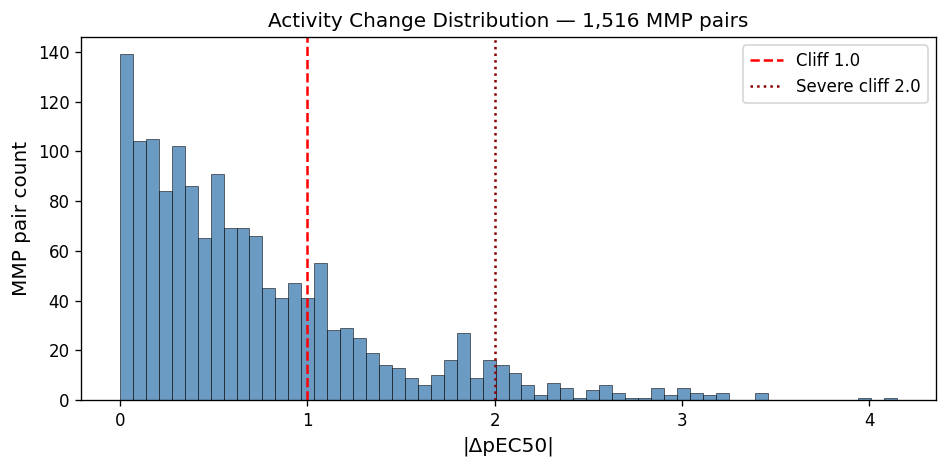

Saved 04_mmp_delta_dist.png


In [5]:
# ── 5. Activity-change distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mmp_df["delta_pec50"], bins=60, color="steelblue",
        edgecolor="k", linewidth=0.4, alpha=0.8)
ax.axvline(1.0, color="red",     linestyle="--", lw=1.5, label="Cliff 1.0")
ax.axvline(2.0, color="darkred", linestyle=":",  lw=1.5, label="Severe cliff 2.0")
ax.set_xlabel("|ΔpEC50|", fontsize=12)
ax.set_ylabel("MMP pair count", fontsize=12)
ax.set_title(f"Activity Change Distribution — {len(mmp_df):,} MMP pairs")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "04_mmp_delta_dist.png", bbox_inches="tight")
plt.show()
print("Saved 04_mmp_delta_dist.png")

In [6]:
# ── 6. Scaffold-out CV: validate MMP predictor ────────────────────────────────
# For each fold, predict hold-out compounds using mean pEC50 of training analogs.
# Only compounds that find ≥1 analog in the training fold are evaluated.

scaffolds = train["scaffold"].tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=42)

cv_rows = []
for fold, (tr_idx, val_idx) in enumerate(splits):
    # Build scaffold index from training fold only
    fold_index = defaultdict(list)
    for i in tr_idx:
        for scaffold, rgroup in precomp_frags[i]:
            fold_index[scaffold].append((rgroup, train_pec50[i]))

    # Predict validation fold
    y_true, y_mmp = [], []
    for i in val_idx:
        y_true.append(train_pec50[i])
        analogs = []
        seen = set()
        for scaffold, rgroup in precomp_frags[i]:
            if scaffold in fold_index:
                for trg, tpec50 in fold_index[scaffold]:
                    if trg != rgroup:
                        key = (scaffold, trg)
                        if key not in seen:
                            analogs.append(tpec50)
                            seen.add(key)
        y_mmp.append(np.mean(analogs) if analogs else np.nan)

    y_true = np.array(y_true)
    y_mmp  = np.array(y_mmp)
    mask   = ~np.isnan(y_mmp)

    m = compute_metrics(y_true[mask], y_mmp[mask]) if mask.sum() > 0 else {}
    m["fold"]      = fold
    m["coverage"]  = float(mask.sum()) / len(val_idx)
    m["n_covered"] = int(mask.sum())
    m["n_val"]     = len(val_idx)
    cv_rows.append(m)

cv_df = pd.DataFrame(cv_rows)
print("MMP predictor CV (scaffold-out, analogs-only compounds)")
print(cv_df[["fold", "n_val", "n_covered", "coverage", "RAE", "MAE", "Spearman"]].to_string(index=False))
print(f"\nMean coverage:  {cv_df['coverage'].mean():.1%}")
print(f"Mean RAE:       {cv_df['RAE'].mean():.4f}")
print(f"Mean Spearman:  {cv_df['Spearman'].mean():.4f}")

MMP predictor CV (scaffold-out, analogs-only compounds)
 fold  n_val  n_covered  coverage      RAE      MAE  Spearman
    0    831        222  0.267148 0.641072 0.714210  0.675500
    1    831        166  0.199759 0.756864 0.748283  0.609189
    2    831        175  0.210590 0.682546 0.666611  0.635771
    3    830        163  0.196386 0.717102 0.721205  0.671280
    4    830        181  0.218072 0.741507 0.749760  0.599351

Mean coverage:  21.8%
Mean RAE:       0.7078
Mean Spearman:  0.6382


In [7]:
# ── 7. Test-set MMP lookup ────────────────────────────────────────────────────
def mmp_lookup(smiles_list, scaffold_index):
    """Return (mmp_preds, n_analogs) arrays.
    mmp_preds[i] = mean pEC50 of training analogs; NaN if none found.
    """
    preds, n_list = [], []
    for smi in tqdm(smiles_list, desc="MMP lookup"):
        mol = Chem.MolFromSmiles(smi) if pd.notna(smi) else None
        if mol is None:
            preds.append(np.nan); n_list.append(0); continue
        analogs = []
        seen = set()
        for scaffold, rgroup in parse_frags(FragmentMol(mol, maxCuts=1, resultsAsMols=False)):
            if scaffold in scaffold_index:
                for _, train_rg, tpec50 in scaffold_index[scaffold]:
                    if train_rg != rgroup:
                        key = (scaffold, train_rg)
                        if key not in seen:
                            analogs.append(tpec50)
                            seen.add(key)
        n_list.append(len(analogs))
        preds.append(np.mean(analogs) if analogs else np.nan)
    return np.array(preds), np.array(n_list)


mmp_preds, n_analogs = mmp_lookup(test["smiles"].tolist(), scaffold_index)

has_analogs = ~np.isnan(mmp_preds)
print(f"Test compounds with MMP analogs:   {has_analogs.sum()} / {len(test)} ({has_analogs.mean():.1%})")
print(f"Median analog count (when present): {np.median(n_analogs[n_analogs > 0]):.1f}")
print(f"Max analog count: {n_analogs.max()}")
print(f"MMP preds range:  {np.nanmin(mmp_preds):.2f} – {np.nanmax(mmp_preds):.2f}")

MMP lookup:   0%|          | 0/513 [00:00<?, ?it/s]

MMP lookup:   9%|▉         | 45/513 [00:00<00:01, 443.68it/s]

MMP lookup:  18%|█▊        | 90/513 [00:00<00:00, 429.28it/s]

MMP lookup:  26%|██▌       | 133/513 [00:00<00:00, 417.11it/s]

MMP lookup:  35%|███▍      | 177/513 [00:00<00:00, 422.89it/s]

...

MMP lookup:  78%|███████▊  | 399/513 [00:00<00:00, 429.10it/s]

MMP lookup:  87%|████████▋ | 445/513 [00:01<00:00, 437.53it/s]

MMP lookup:  95%|█████████▌| 489/513 [00:01<00:00, 422.87it/s]

MMP lookup: 100%|██████████| 513/513 [00:01<00:00, 424.46it/s]

Test compounds with MMP analogs:   340 / 513 (66.3%)
Median analog count (when present): 2.0
Max analog count: 10
MMP preds range:  1.78 – 6.69


In [8]:
# ── 8. Adaptive blend ────────────────────────────────────────────────────────
# Weight the MMP prediction by min(MAX_WEIGHT, MAX_WEIGHT * n_analogs / RAMP_AT)
# so that a compound with 1 analog gets 0.12 weight, and ≥5 analogs get 0.60.

MAX_WEIGHT = 0.60
RAMP_AT    = 5

blend_w     = np.minimum(MAX_WEIGHT, MAX_WEIGHT * n_analogs / RAMP_AT)
final_preds = np.where(
    has_analogs,
    blend_w * mmp_preds + (1.0 - blend_w) * base_preds,
    base_preds,
)

# Safety clip to training range ± 0.5 log-units
lo = train["pec50"].min() - 0.5
hi = train["pec50"].max() + 0.5
final_preds = np.clip(final_preds, lo, hi)

print(f"Final preds range:  {final_preds.min():.3f} – {final_preds.max():.3f}")
print(f"Mean shift vs base: {(final_preds - base_preds).mean():+.4f}")
print(f"Max |shift|:        {np.abs(final_preds - base_preds).max():.3f}")
print(f"Compounds modified:  {(np.abs(final_preds - base_preds) > 0.01).sum()}")

Final preds range:  2.743 – 5.875
Mean shift vs base: +0.1451
Max |shift|:        1.468
Compounds modified:  337


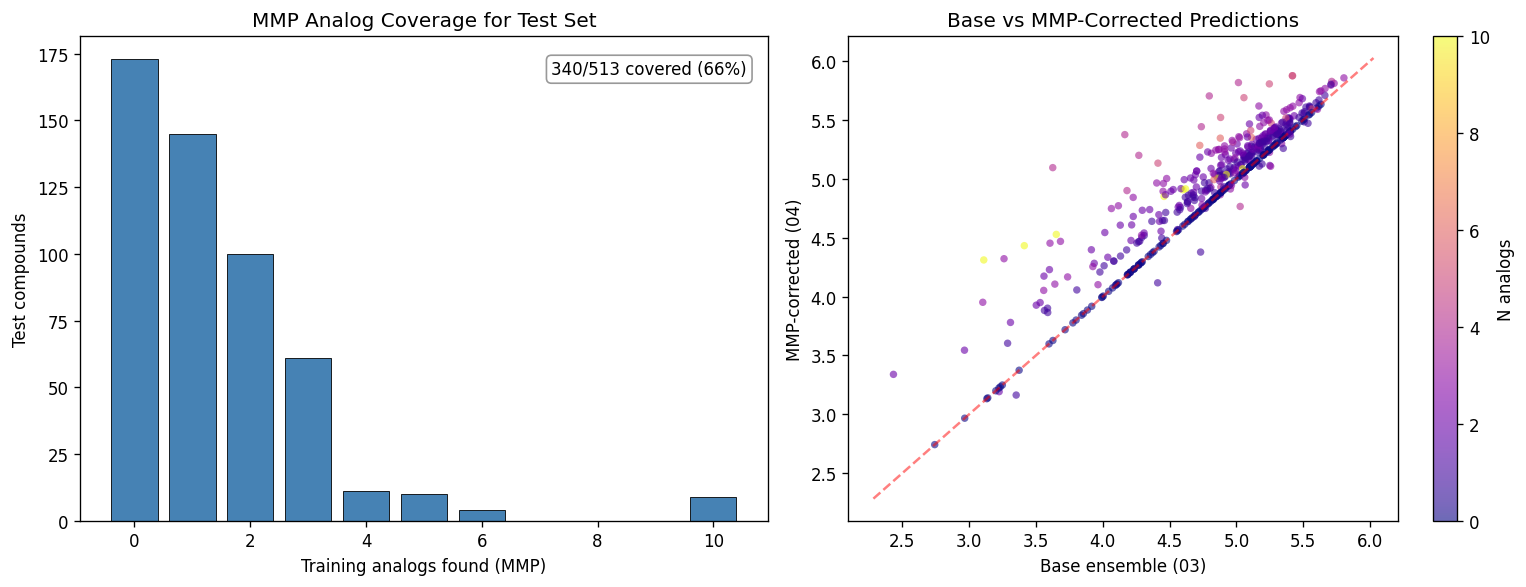

Saved 04_mmp_coverage.png


In [9]:
# ── 9. Coverage visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of analog counts
ax = axes[0]
vals, cnts = np.unique(n_analogs, return_counts=True)
ax.bar(vals, cnts, color="steelblue", edgecolor="k", linewidth=0.5)
ax.set_xlabel("Training analogs found (MMP)")
ax.set_ylabel("Test compounds")
ax.set_title("MMP Analog Coverage for Test Set")
ax.text(0.97, 0.95,
        f"{has_analogs.sum()}/513 covered ({has_analogs.mean():.0%})",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

# Scatter: base vs MMP-corrected, coloured by n_analogs
ax = axes[1]
sc = ax.scatter(base_preds, final_preds, c=n_analogs, cmap="plasma",
                alpha=0.6, s=20, linewidths=0)
plt.colorbar(sc, ax=ax, label="N analogs")
lo_ax = min(base_preds.min(), final_preds.min()) - 0.15
hi_ax = max(base_preds.max(), final_preds.max()) + 0.15
ax.plot([lo_ax, hi_ax], [lo_ax, hi_ax], "r--", lw=1.5, alpha=0.5)
ax.set_xlabel("Base ensemble (03)")
ax.set_ylabel("MMP-corrected (04)")
ax.set_title("Base vs MMP-Corrected Predictions")

plt.tight_layout()
plt.savefig(FIGURES / "04_mmp_coverage.png", bbox_inches="tight")
plt.show()
print("Saved 04_mmp_coverage.png")

In [10]:
# ── 10. Save submission ───────────────────────────────────────────────────────
submission = pd.DataFrame({
    "Molecule Name": test["name"].values,
    "SMILES":        test["smiles"].values,
    "pEC50":         final_preds,
})

assert len(submission) == 513, f"Expected 513, got {len(submission)}"
assert submission["pEC50"].notna().all(), "NaN predictions found!"

out_path = SUBMISSIONS / "04_mmp_corrected.csv"
submission.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(submission["pEC50"].describe().round(3))

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\04_mmp_corrected.csv
count    513.000
mean       4.961
std        0.540
min        2.743
25%        4.738
50%        5.094
75%        5.346
max        5.875
Name: pEC50, dtype: float64
